<a href="https://colab.research.google.com/github/dhans2007/ML_LAB/blob/main/ML_EXP_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DHANESH VC 24BAD018
EXPERIMENT-09

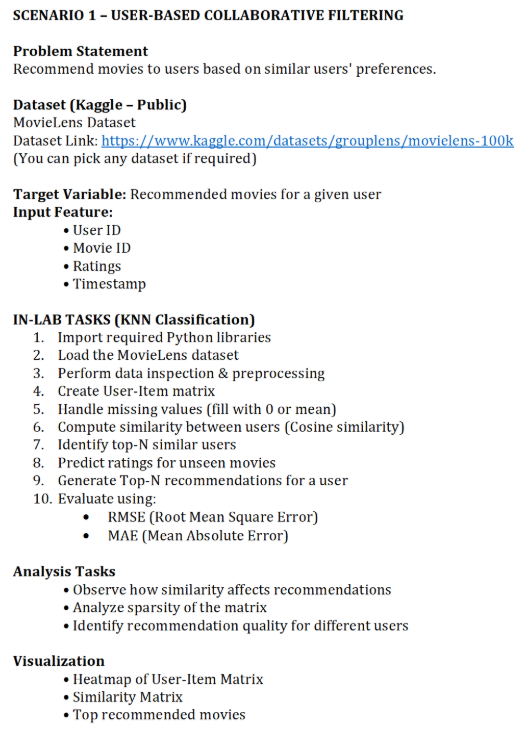

In [ ]:
#import libraries
print("DHANESH VC 24BAD018")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt

DHANESH VC 24BAD018


In [ ]:
# Load dataset
ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

data = pd.merge(ratings, movies, on="movieId")

data.rename(columns={
    "userId": "user_id",
    "movieId": "movie_id",
    "rating": "rating",
    "timestamp": "timestamp",
    "title": "title"
}, inplace=True)

data.head()

,user_id,movie_id,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [ ]:
#Data Inspection
print("Shape:", data.shape)
print("\nMissing values:\n", data.isnull().sum())

print("\nUnique Users:", data['user_id'].nunique())
print("Unique Movies:", data['movie_id'].nunique())

data.describe()

Shape: (100836, 6)

Missing values:
 user_id      0
movie_id     0
rating       0
timestamp    0
title        0
genres       0
dtype: int64

Unique Users: 610
Unique Movies: 9724


,user_id,movie_id,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


In [ ]:
#Create user-item matrix
user_item_matrix = data.pivot_table(index='user_id', columns='title', values='rating')

user_item_matrix.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
user_id,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Handling missing values
user_item_matrix_filled = user_item_matrix.fillna(0)
user_item_matrix_filled.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
user_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#Compute cosine similarity
user_similarity = cosine_similarity(user_item_matrix_filled)

user_similarity_df = pd.DataFrame(user_similarity,
                                  index=user_item_matrix.index,
                                  columns=user_item_matrix.index)

user_similarity_df.head()

user_id,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
user_id,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.027283,0.059720,0.194395,0.129080,0.128152,0.158744,0.136968,0.064263,0.016875,...,0.080554,0.164455,0.221486,0.070669,0.153625,0.164191,0.269389,0.291097,0.093572,0.145321
2,0.027283,1.000000,0.000000,0.003726,0.016614,0.025333,0.027585,0.027257,0.000000,0.067445,...,0.202671,0.016866,0.011997,0.000000,0.000000,0.028429,0.012948,0.046211,0.027565,0.102427
3,0.059720,0.000000,1.000000,0.002251,0.005020,0.003936,0.000000,0.004941,0.000000,0.000000,...,0.005048,0.004892,0.024992,0.000000,0.010694,0.012993,0.019247,0.021128,0.000000,0.032119
4,0.194395,0.003726,0.002251,1.000000,0.128659,0.088491,0.115120,0.062969,0.011361,0.031163,...,0.085938,0.128273,0.307973,0.052985,0.084584,0.200395,0.131746,0.149858,0.032198,0.107683
5,0.129080,0.016614,0.005020,0.128659,1.000000,0.300349,0.108342,0.429075,0.000000,0.030611,...,0.068048,0.418747,0.110148,0.258773,0.148758,0.106435,0.152866,0.135535,0.261232,0.060792


In [ ]:
#Find top-N similar users
def get_similar_users(user_id, n=5):
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:n+1]
    return similar_users

# Example
get_similar_users(1, 5)

,1
user_id,
266,0.357408
313,0.351562
368,0.345127
57,0.345034
91,0.334727


In [ ]:
#Predict ratings
def predict_ratings(user_id):
    similar_users = get_similar_users(user_id, 5)
    similar_users_ids = similar_users.index

    similar_ratings = user_item_matrix_filled.loc[similar_users_ids]

    weighted_sum = np.dot(similar_users.values, similar_ratings)
    sim_sum = np.sum(similar_users.values)

    predicted_ratings = weighted_sum / sim_sum

    return pd.Series(predicted_ratings, index=user_item_matrix.columns)

# Example
predicted = predict_ratings(1)
predicted.head()

,0
title,
'71 (2014),0.0
'Hellboy': The Seeds of Creation (2004),0.0
'Round Midnight (1986),0.0
'Salem's Lot (2004),0.0
'Til There Was You (1997),0.0


In [ ]:
#Top-N recommendations
def recommend_movies(user_id, n=5):
    predicted_ratings = predict_ratings(user_id)

    already_rated = user_item_matrix.loc[user_id].dropna().index

    recommendations = predicted_ratings.drop(already_rated)

    top_recommendations = recommendations.sort_values(ascending=False).head(n)

    return top_recommendations

# Example
recommend_movies(1, 5)

,0
title,
Aliens (1986),4.801002
"Hunt for Red October, The (1990)",4.298950
Blade Runner (1982),4.004742
Terminator 2: Judgment Day (1991),4.003711
Die Hard (1988),4.000000


In [ ]:
#Evalation metrices
# Prediction matrix
predicted_matrix = np.dot(user_similarity, user_item_matrix_filled) / np.array([np.abs(user_similarity).sum(axis=1)]).T

actual = user_item_matrix_filled.values.flatten()
predicted = predicted_matrix.flatten()

# Ignore zero values
mask = actual > 0
actual = actual[mask]
predicted = predicted[mask]

rmse = sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 3.0732205951143596
MAE: 2.8962676149211024


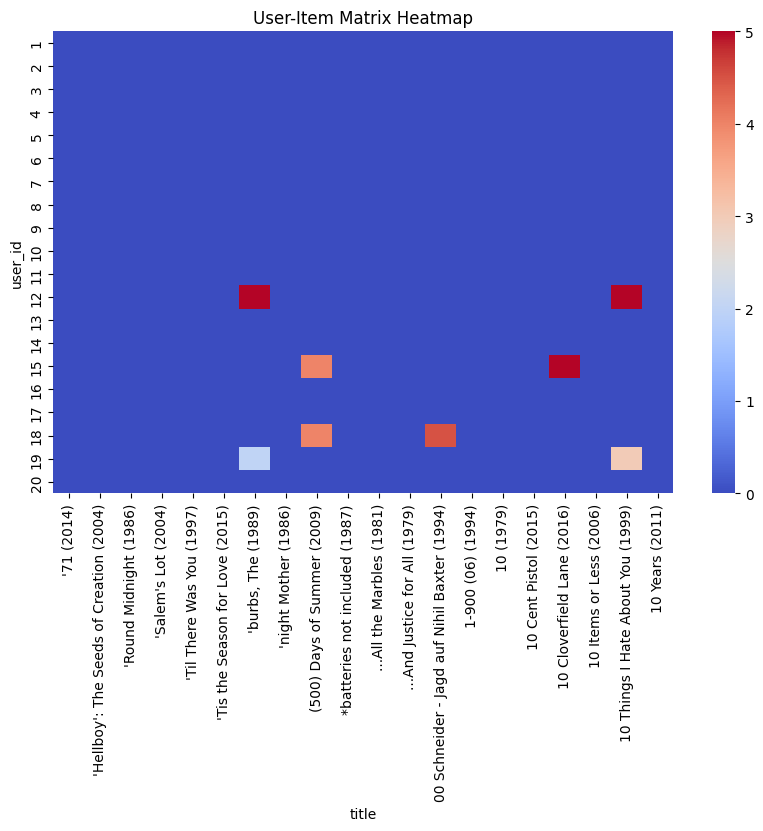

In [ ]:
#Visualization
#User-item heatmap
plt.figure(figsize=(10,6))
sns.heatmap(user_item_matrix_filled.iloc[:20, :20], cmap="coolwarm")
plt.title("User-Item Matrix Heatmap")
plt.show()

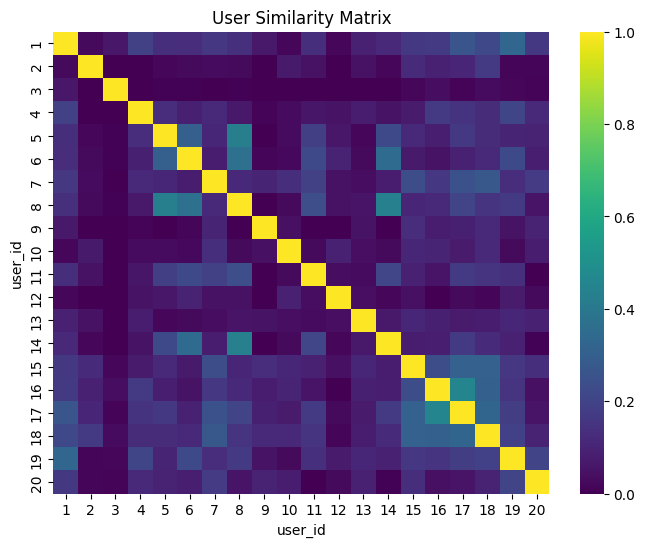

In [ ]:
#Similarity heatmap
plt.figure(figsize=(8,6))
sns.heatmap(user_similarity_df.iloc[:20, :20], cmap="viridis")
plt.title("User Similarity Matrix")
plt.show()

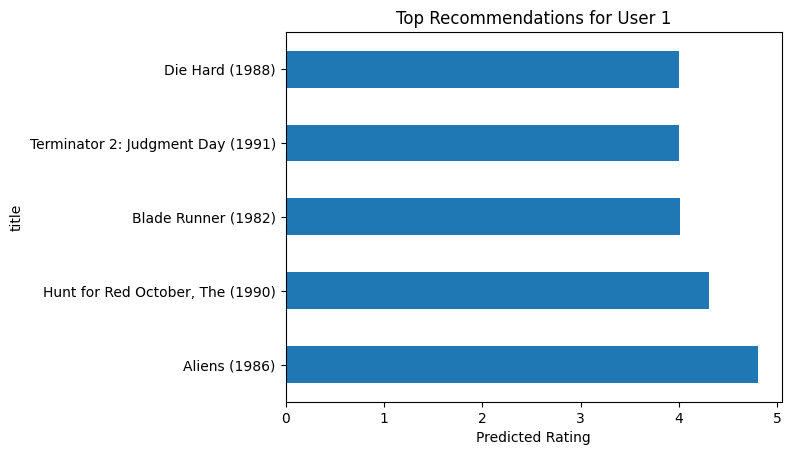

In [ ]:
#Recommendation heatmap
user_id = 1
recs = recommend_movies(user_id, 5)

recs.plot(kind='barh')
plt.title(f"Top Recommendations for User {user_id}")
plt.xlabel("Predicted Rating")
plt.show()

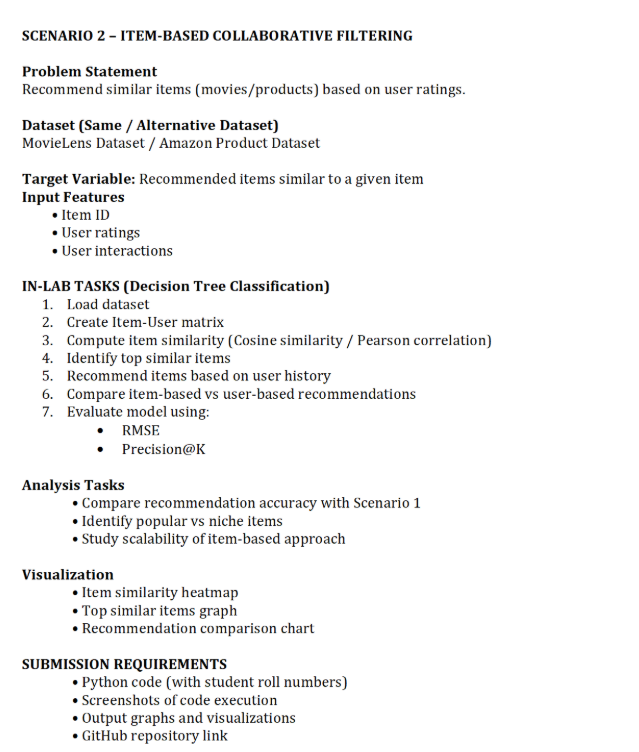

In [ ]:
#Import Libraries
#DHANESH VC 24BAD055
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
from math import sqrt

In [ ]:
#Load the dataset
ratings = pd.read_csv("dataset/ratings.csv")
movies = pd.read_csv("dataset/movies.csv")

data = pd.merge(ratings, movies, on="movieId")

data.rename(columns={
    "userId": "user_id",
    "movieId": "movie_id",
    "rating": "rating",
    "title": "title"
}, inplace=True)

data.head()

,user_id,movie_id,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [ ]:
#Creating item-user matrix
item_user_matrix = data.pivot_table(index='title', columns='user_id', values='rating')

item_user_matrix.head()

user_id,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
title,,,,,,,,,,,,,,,,,,,,,
'71 (2014),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
'Hellboy': The Seeds of Creation (2004),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
'Round Midnight (1986),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
'Salem's Lot (2004),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
'Til There Was You (1997),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Handling missing values
item_user_filled = item_user_matrix.fillna(0)

In [ ]:
#Compute item-similarity]
item_similarity = cosine_similarity(item_user_filled)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_matrix.index,
    columns=item_user_matrix.index
)

item_similarity_df.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
title,,,,,,,,,,,,,,,,,,,,,
'71 (2014),1.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.141653,0.0,...,0.0,0.342055,0.543305,0.707107,0.0,0.0,0.139431,0.327327,0.0,0.0
'Hellboy': The Seeds of Creation (2004),0.0,1.000000,0.707107,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0
'Round Midnight (1986),0.0,0.707107,1.000000,0.000000,0.000000,0.0,0.176777,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0
'Salem's Lot (2004),0.0,0.000000,0.000000,1.000000,0.857493,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0
'Til There Was You (1997),0.0,0.000000,0.000000,0.857493,1.000000,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0


In [ ]:
#Final top-similar items
def get_similar_items(movie_title, n=5):
    similar_items = item_similarity_df[movie_title].sort_values(ascending=False)[1:n+1]
    return similar_items

# Example
get_similar_items("Toy Story (1995)", 5)

title
Toy Story 2 (1999)                           0.572601
Jurassic Park (1993)                         0.565637
Independence Day (a.k.a. ID4) (1996)         0.564262
Star Wars: Episode IV - A New Hope (1977)    0.557388
Forrest Gump (1994)                          0.547096
Name: Toy Story (1995), dtype: float64

In [ ]:
#Recommend items based on user history
def recommend_item_based(user_id, n=5):
    user_ratings = item_user_filled[user_id]

    rated_items = user_ratings[user_ratings > 0]

    scores = {}
    similarity_sums = {}

    for item in rated_items.index:
        similarity_scores = item_similarity_df[item]

        for similar_item, sim in similarity_scores.items():
            if user_ratings[similar_item] == 0:
                scores[similar_item] = scores.get(similar_item, 0) + sim * rated_items[item]
                similarity_sums[similar_item] = similarity_sums.get(similar_item, 0) + sim

    predicted_ratings = {}
    for item in scores:
        if similarity_sums[item] != 0:
            predicted_ratings[item] = scores[item] / similarity_sums[item]

    return pd.Series(predicted_ratings).sort_values(ascending=False).head(n)

recommend_item_based(1,5)

recommend_item_based(100,120)

Too Late for Tears (1949)                               5.000000
Villain (1971)                                          5.000000
Pearl Jam Twenty (2011)                                 4.500000
Carabineers, The (Carabiniers, Les) (1963)              4.500000
Ring, The (1927)                                        4.500000
                                                          ...   
Disgrace (2008)                                         4.200971
The True Memoirs of an International Assassin (2016)    4.199201
Rough Night (2017)                                      4.197726
The Boss Baby (2017)                                    4.196513
Death Sentence (2007)                                   4.194910
Length: 120, dtype: float64

In [ ]:
#RMSE Evaluation
predicted_matrix = np.dot(item_similarity, item_user_filled) / np.array([np.abs(item_similarity).sum(axis=1)]).T

actual = item_user_filled.values.flatten()
predicted = predicted_matrix.flatten()

mask = actual > 0
actual = actual[mask]
predicted = predicted[mask]

rmse = sqrt(mean_squared_error(actual, predicted))

print("RMSE:", rmse)

RMSE: 3.1456882806620725


In [ ]:
#Precision@K
def precision_at_k(user_id, k=5, threshold=3.5):
    recommended = recommend_item_based(user_id, k)

    actual_ratings = item_user_filled[user_id]

    relevant = actual_ratings[actual_ratings >= threshold].index

    recommended_items = recommended.index

    relevant_recommended = [item for item in recommended_items if item in relevant]

    precision = len(relevant_recommended) / k

    return precision

precision_at_k(1, 5)

0.0

In [ ]:
#User-based
user_item_matrix = data.pivot_table(index='user_id', columns='title', values='rating').fillna(0)

user_similarity = cosine_similarity(user_item_matrix)

def recommend_user_based(user_id, n=5):
    sim_scores = user_similarity[user_id - 1]
    similar_users = np.argsort(sim_scores)[::-1][1:6]

    weighted_ratings = np.dot(sim_scores[similar_users], user_item_matrix.iloc[similar_users])
    predicted = weighted_ratings / np.sum(sim_scores[similar_users])

    predicted_series = pd.Series(predicted, index=user_item_matrix.columns)

    already_rated = user_item_matrix.loc[user_id]
    predicted_series = predicted_series[already_rated == 0]

    return predicted_series.sort_values(ascending=False).head(n)


recommend_user_based(1, 5)

title
Aliens (1986)                        4.801002
Hunt for Red October, The (1990)     4.298950
Blade Runner (1982)                  4.004742
Terminator 2: Judgment Day (1991)    4.003711
Die Hard (1988)                      4.000000
dtype: float64

In [ ]:
#Comparing recommendations
user_id = 1

item_based = recommend_item_based(user_id, 5)
user_based = recommend_user_based(user_id, 5)

print("Item-Based:\n", item_based)
print("\nUser-Based:\n", user_based)

Item-Based:
 Ferris Bueller's Day Off (1986)    352.684010
Die Hard (1988)                    330.949884
Breakfast Club, The (1985)         328.180507
Fifth Element, The (1997)          326.437374
Aliens (1986)                      323.117648
dtype: float64

User-Based:
 title
Aliens (1986)                        4.801002
Hunt for Red October, The (1990)     4.298950
Blade Runner (1982)                  4.004742
Terminator 2: Judgment Day (1991)    4.003711
Die Hard (1988)                      4.000000
dtype: float64


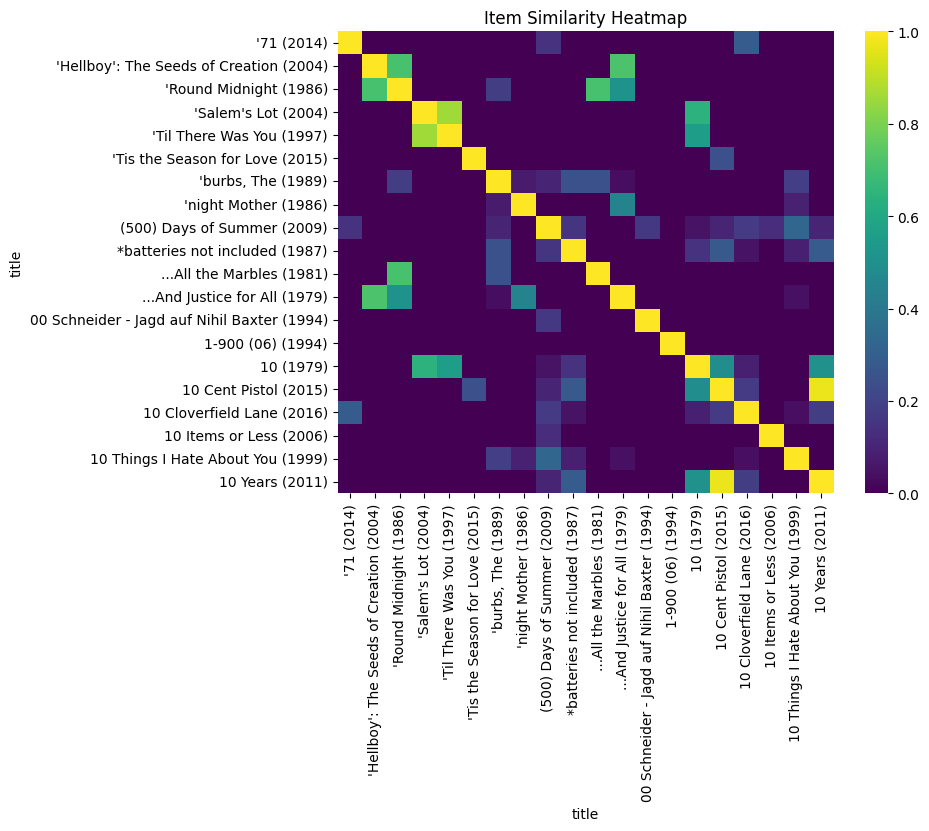

In [ ]:
#Visualization
#Item-similarity heatmap
plt.figure(figsize=(8,6))
sns.heatmap(item_similarity_df.iloc[:20, :20], cmap="viridis")
plt.title("Item Similarity Heatmap")
plt.show()

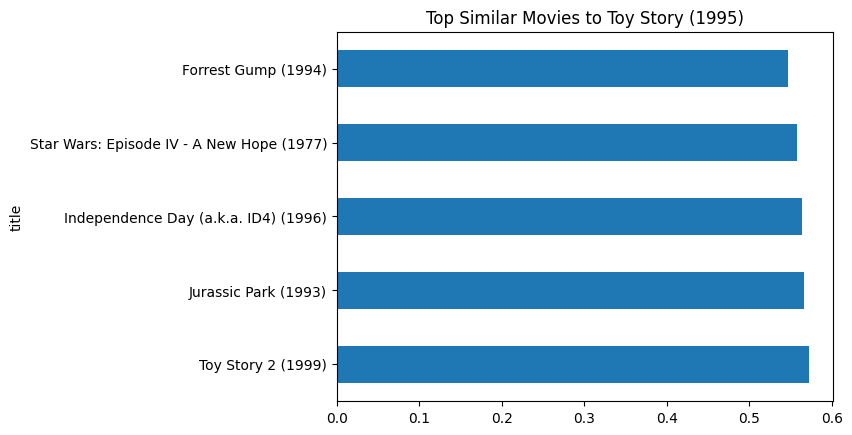

In [ ]:
#Top-similar Item-graph
movie = "Toy Story (1995)"
similar_items = get_similar_items(movie, 5)

similar_items.plot(kind='barh')
plt.title(f"Top Similar Movies to {movie}")
plt.show()

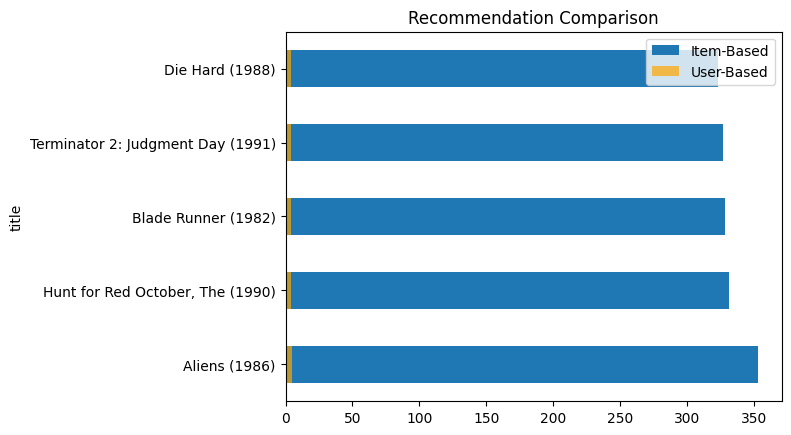

In [ ]:
#Recommendation Comparision chart
item_based.plot(kind='barh', label='Item-Based')
user_based.plot(kind='barh', color='orange', alpha=0.7, label='User-Based')

plt.legend()
plt.title("Recommendation Comparison")
plt.show()